In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
!pip install -q kagglehub

In [6]:
import kagglehub

path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
Dataset downloaded to:
/kaggle/input/garbage-classification-v2


In [7]:
import os

dataset_path = "/kaggle/input/garbage-classification-v2"

print("Contents of dataset:")
print(os.listdir(dataset_path))

Contents of dataset:
['standardized_384', 'original', 'standardized_256']


In [8]:
import os

data_path = "/kaggle/input/garbage-classification-v2/standardized_256"

print("Classes/Folders:")
print(os.listdir(data_path))


Classes/Folders:
['metal', 'glass', 'biological', 'paper', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'plastic']


In [9]:
import os

class_counts = {}

for class_name in os.listdir(data_path):
    class_path = os.path.join(data_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Number of images per class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Number of images per class:

metal: 930
glass: 1736
biological: 699
paper: 1336
battery: 756
trash: 453
cardboard: 1411
shoes: 1449
clothes: 1892
plastic: 1597


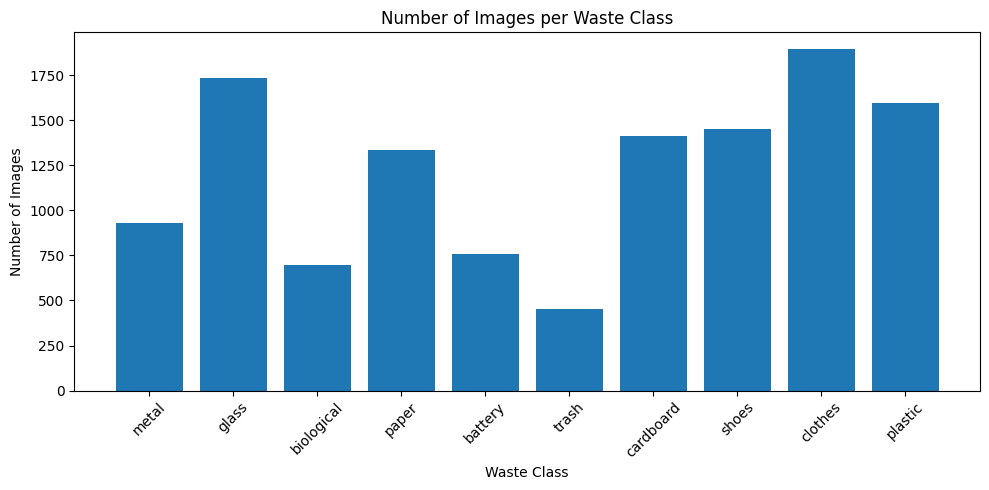

In [10]:
import matplotlib.pyplot as plt

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(classes, counts)
plt.title("Number of Images per Waste Class")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
import tensorflow as tf

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:", train_dataset.class_names)

Found 12259 files belonging to 10 classes.
Using 9808 files for training.
Found 12259 files belonging to 10 classes.
Using 2451 files for validation.
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [12]:
# Create the validation portion (10%)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split the 20% reserved data into two equal parts
val_batches = tf.data.experimental.cardinality(validation_dataset)

test_size = val_batches // 2

test_dataset = validation_dataset.take(test_size)
validation_dataset = validation_dataset.skip(test_size)

print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Found 12259 files belonging to 10 classes.
Using 2451 files for validation.
Training batches: 307
Validation batches: 39
Test batches: 38


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.15)
], name="data_augmentation")

print("Data augmentation created successfully.")

Data augmentation created successfully.


In [14]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get the class names in the same order TensorFlow uses
class_names = train_dataset.class_names

# Count training samples for each class
train_class_counts = {}

for class_name in class_names:
    class_path = os.path.join(data_path, class_name)
    total_images = len(os.listdir(class_path))
    train_class_counts[class_name] = round(total_images * 0.8)

# Create labels based on the class counts
y_classes = []

for index, class_name in enumerate(class_names):
    y_classes.extend([index] * train_class_counts[class_name])

# Calculate class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=np.array(y_classes)
)

class_weights = {
    index: weight
    for index, weight in enumerate(class_weights_array)
}

print("Class weights:")
for index, class_name in enumerate(class_names):
    print(f"{class_name}: {class_weights[index]:.4f}")


Class weights:
battery: 1.6212
biological: 1.7546
cardboard: 0.8687
clothes: 0.6478
glass: 0.7061
metal: 1.3183
paper: 0.9175
plastic: 0.7674
shoes: 0.8462
trash: 2.7094


In [15]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Data augmentation
    data_augmentation,

    # Rescale pixel values from 0-255 to 0-1
    layers.Rescaling(1./255),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # Convolutional Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # Classification section
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "/content/best_waste_classifier.keras",
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("Training callbacks are ready.")

Training callbacks are ready.


In [17]:
EPOCHS = 30

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr
    ]
)

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - accuracy: 0.2002 - loss: 2.1415 - val_accuracy: 0.3344 - val_loss: 1.8302 - learning_rate: 0.0010
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 30s 98ms/step - accuracy: 0.3321 - loss: 1.8382 - val_accuracy: 0.3636 - val_loss: 1.7041 - learning_rate: 0.0010
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 30s 98ms/step - accuracy: 0.3772 - loss: 1.7136 - val_accuracy: 0.4291 - val_loss: 1.5779 - learning_rate: 0.0010
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.4178 - loss: 1.6388 - val_accuracy: 0.4372 - val_loss: 1.6749 - learning_rate: 0.0010
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - accuracy: 0.4407 - loss: 1.5654 - val_accuracy: 0.5020 - val_loss: 1.4068 - learning_rate: 0.0010
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.4627 - loss: 1.5158 - val_accuracy: 0.5182 - val_loss: 1.3468 - learning_rate: 0.0010
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.4831 - 

In [18]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6480 - loss: 1.0793
Test Loss: 1.0793
Test Accuracy: 0.6480


In [19]:
from sklearn.metrics import classification_report
import numpy as np

# Get the true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

     battery     0.5804    0.8442    0.6878        77
  biological     0.8750    0.7273    0.7943        77
   cardboard     0.6713    0.7385    0.7033       130
     clothes     0.8295    0.7725    0.8000       189
       glass     0.7900    0.5163    0.6245       153
       metal     0.4414    0.6465    0.5246        99
       paper     0.5086    0.6953    0.5875       128
     plastic     0.6441    0.4497    0.5296       169
       shoes     0.7008    0.6312    0.6642       141
       trash     0.5893    0.6226    0.6055        53

    accuracy                         0.6521      1216
   macro avg     0.6630    0.6644    0.6521      1216
weighted avg     0.6782    0.6521    0.6535      1216



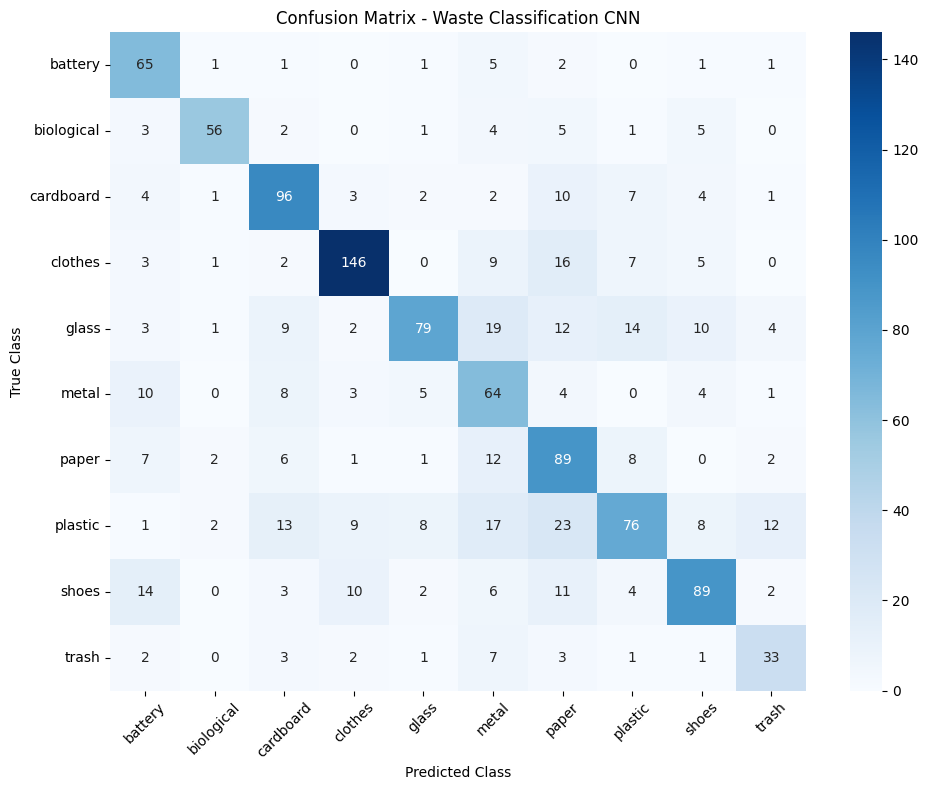

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Waste Classification CNN")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

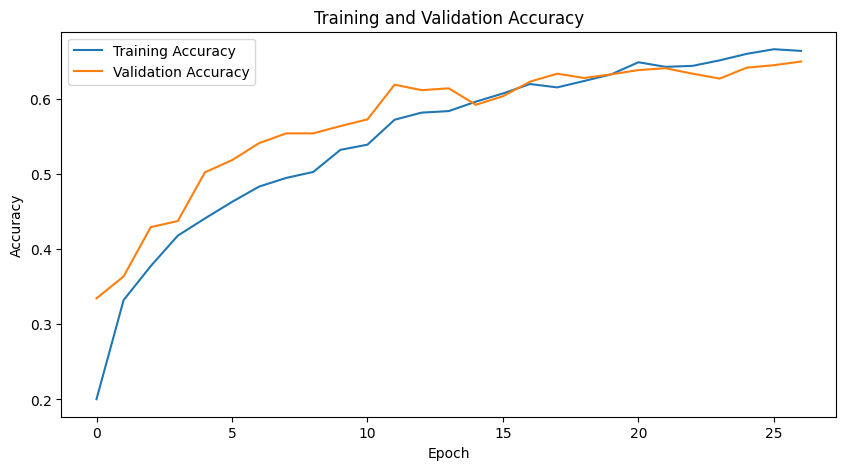

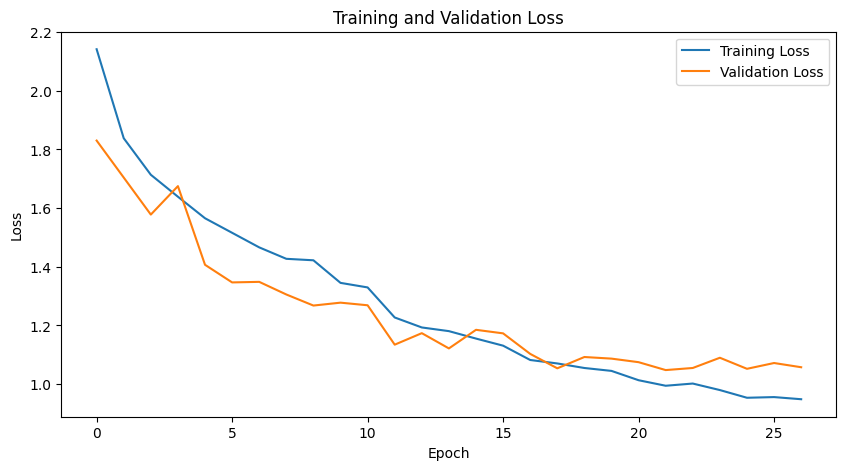

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [22]:
# Save the trained CNN
model.save("/content/waste_classifier.keras")

# Save the class names
import json

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model saved successfully.")
print("Class names saved successfully.")

Model saved successfully.
Class names saved successfully.


In [23]:
import os

model_path = "/content/waste_classifier.keras"
class_names_path = "/content/class_names.json"

print("Model exists:", os.path.exists(model_path))
print("Model size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")

print("Class names exists:", os.path.exists(class_names_path))

Model exists: True
Model size: 196.55 MB
Class names exists: True


In [24]:
!pip install -q fastapi uvicorn python-multipart pillow

In [25]:
%%writefile app.py

from fastapi import FastAPI, File, UploadFile
from PIL import Image
import tensorflow as tf
import numpy as np
import json
import io

app = FastAPI(
    title="GreenCycle Waste Classification API",
    description="CNN-based waste classification API",
    version="1.0"
)

# Load trained model
model = tf.keras.models.load_model("waste_classifier.keras")

# Load class names
with open("class_names.json", "r") as f:
    class_names = json.load(f)


@app.get("/")
def home():
    return {
        "message": "GreenCycle Waste Classification API is running"
    }


@app.get("/health")
def health():
    return {
        "status": "healthy"
    }


@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    # Read uploaded image
    image_bytes = await file.read()
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

    # Resize image to model input size
    image = image.resize((256, 256))

    # Convert image to NumPy array
    image_array = np.array(image, dtype=np.float32)

    # Normalize pixel values
    image_array = image_array / 255.0

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Make prediction
    predictions = model.predict(image_array, verbose=0)

    predicted_index = int(np.argmax(predictions[0]))
    predicted_class = class_names[predicted_index]
    confidence = float(predictions[0][predicted_index])

    return {
        "predicted_class": predicted_class,
        "confidence": round(confidence, 4)
    }


Writing app.py


In [26]:
import nest_asyncio
import uvicorn
import threading

nest_asyncio.apply()

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("FastAPI server started on port 8000")

FastAPI server started on port 8000


Exception in thread Thread-19 (run_server):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_808/2381909610.py", line 8, in run_server
NameError: name 'app' is not defined


In [27]:
import importlib.util

spec = importlib.util.spec_from_file_location("app_module", "/content/app.py")
app_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(app_module)

app = app_module.app

print("FastAPI app loaded successfully.")

FastAPI app loaded successfully.


In [28]:
import nest_asyncio
import uvicorn
import threading

nest_asyncio.apply()

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("FastAPI server is running.")

FastAPI server is running.


In [29]:
import requests

response = requests.get("http://127.0.0.1:8000/health")

print("Status code:", response.status_code)
print("Response:", response.json())

INFO:     127.0.0.1:52788 - "GET /health HTTP/1.1" 200 OK
Status code: 200
Response: {'status': 'healthy'}


In [30]:
import os
import random

# Select a real image from the test dataset
test_image_path = None

for class_name in class_names:
    class_path = os.path.join(data_path, class_name)
    images = [
        os.path.join(class_path, f)
        for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if images:
        test_image_path = random.choice(images)
        break

print("Test image:")
print(test_image_path)

Test image:
/kaggle/input/garbage-classification-v2/standardized_256/battery/battery_547.jpg


In [31]:
import requests

with open(test_image_path, "rb") as image_file:
    response = requests.post(
        "http://127.0.0.1:8000/predict",
        files={"file": ("battery_test.jpg", image_file, "image/jpeg")}
    )

print("Status code:", response.status_code)
print("Prediction:", response.json())

INFO:     127.0.0.1:44180 - "POST /predict HTTP/1.1" 200 OK
Status code: 200
Prediction: {'predicted_class': 'plastic', 'confidence': 0.7531}


In [32]:
%%writefile requirements.txt

fastapi
uvicorn
python-multipart
pillow
tensorflow
numpy

Writing requirements.txt


In [33]:
import os
import shutil

deployment_folder = "/content/greencycle_api"

os.makedirs(deployment_folder, exist_ok=True)

# Copy required files
shutil.copy("/content/app.py", deployment_folder)
shutil.copy("/content/requirements.txt", deployment_folder)
shutil.copy("/content/waste_classifier.keras", deployment_folder)
shutil.copy("/content/class_names.json", deployment_folder)

print("Deployment files:")
print(os.listdir(deployment_folder))

Deployment files:
['app.py', 'requirements.txt', 'class_names.json', 'waste_classifier.keras']


In [34]:
%%writefile /content/greencycle_api/README.md
# GreenCycle Waste Classification API

A CNN-based waste classification system developed for GreenCycle Waste Management.

## Waste Classes

The model classifies images into 10 categories:

- Battery
- Biological
- Cardboard
- Clothes
- Glass
- Metal
- Paper
- Plastic
- Shoes
- Trash

## Model

The model is a convolutional neural network built from scratch using TensorFlow and Keras.

It uses:
- Data augmentation
- Dropout
- Class weighting
- Early stopping
- Learning-rate reduction

## API Endpoints

GET /health

POST /predict

The prediction endpoint accepts an image and returns the predicted waste class and confidence score.

## Evaluation

Test accuracy: approximately 65%.

Battery recall: approximately 84%.

The project includes the classification report and confusion matrix.

## Deployment Considerations

The model should not be trusted immediately on a real recycling line. Real conveyor-belt conditions may include poor lighting, wet or dirty objects, overlapping waste, partially hidden objects, and camera angles that differ from the training data.

Battery detection is particularly important because missing a battery can create a safety risk. Before deployment, GreenCycle should test the model using real conveyor-belt images, improve battery detection, and include appropriate human or safety verification before fully automated sorting.

Writing /content/greencycle_api/README.md


In [35]:
import os

deployment_folder = "/content/greencycle_api"

print("Deployment folder contents:")
for file in os.listdir(deployment_folder):
    file_path = os.path.join(deployment_folder, file)
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"{file} — {size_mb:.2f} MB")

Deployment folder contents:
app.py — 0.00 MB
README.md — 0.00 MB
requirements.txt — 0.00 MB
class_names.json — 0.00 MB
waste_classifier.keras — 196.55 MB


In [36]:
import shutil

shutil.make_archive(
    "/content/greencycle_api",
    "zip",
    "/content/greencycle_api"
)

print("Project ZIP created successfully.")

Project ZIP created successfully.


In [37]:
!apt-get -qq install git-lfs
!git lfs install

print("Git LFS is ready.")

Selecting previously unselected package git-lfs.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...
Git LFS initialized.
Git LFS is ready.


In [38]:
!git config --global user.name "Olumatin"
!git config --global user.email "YOUR_GITHUB_EMAIL"

In [39]:
!git ls-remote https://github.com/Olumatin/GreenCycle-Waste-Classification.git

In [40]:
%cd /content

!git clone https://github.com/Olumatin/GreenCycle-Waste-Classification.git

print("Repository cloned successfully.")

/content
Cloning into 'GreenCycle-Waste-Classification'...
Repository cloned successfully.


In [41]:
import shutil
import os

source = "/content/greencycle_api"
destination = "/content/GreenCycle-Waste-Classification"

for file_name in os.listdir(source):
    source_file = os.path.join(source, file_name)
    destination_file = os.path.join(destination, file_name)

    if os.path.isfile(source_file):
        shutil.copy2(source_file, destination_file)

print("Project files copied successfully.")
print(os.listdir(destination))

Project files copied successfully.
['.git', 'app.py', 'README.md', 'requirements.txt', 'class_names.json', 'waste_classifier.keras']


In [42]:
%cd /content/GreenCycle-Waste-Classification

!git lfs track "waste_classifier.keras"

!git add .gitattributes

print("Git LFS is now tracking the model file.")

/content/GreenCycle-Waste-Classification
Tracking "waste_classifier.keras"
Git LFS is now tracking the model file.


In [43]:
!git add app.py README.md requirements.txt class_names.json waste_classifier.keras

print("All project files added to Git.")

All project files added to Git.


In [44]:
!git status

On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .gitattributes
	new file:   README.md
	new file:   app.py
	new file:   class_names.json
	new file:   requirements.txt
	new file:   waste_classifier.keras



In [45]:
!git commit -m "Initial GreenCycle waste classification API"

[main (root-commit) 1af680d] Initial GreenCycle waste classification API
 6 files changed, 129 insertions(+)
 create mode 100644 .gitattributes
 create mode 100644 README.md
 create mode 100644 app.py
 create mode 100644 class_names.json
 create mode 100644 requirements.txt
 create mode 100644 waste_classifier.keras


In [46]:
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [49]:
%cd /content/GreenCycle-Waste-Classification

!git remote set-url origin https://Olumatin@github.com/Olumatin/GreenCycle-Waste-Classification.git

print("GitHub remote updated successfully.")

/content/GreenCycle-Waste-Classification
GitHub remote updated successfully.


In [50]:
from getpass import getpass

github_token = getpass("Paste your GitHub token here: ")

Paste your GitHub token here: ··········


In [51]:
import subprocess

remote_url = "https://Olumatin@github.com/Olumatin/GreenCycle-Waste-Classification.git"

result = subprocess.run(
    ["git", "push", "-u", remote_url, "main"],
    input=f"{github_token}\n",
    text=True,
    capture_output=True
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
else:
    print("Successfully pushed to GitHub!")


fatal: could not read Password for 'https://Olumatin@github.com': No such device or address



In [52]:
import os
import subprocess

# Create a temporary password helper that Git can use
askpass_path = "/content/git-askpass.sh"

with open(askpass_path, "w") as f:
    f.write("""#!/bin/sh
echo "$GITHUB_TOKEN"
""")

os.chmod(askpass_path, 0o700)

# Give Git the token through an environment variable
env = os.environ.copy()
env["GITHUB_TOKEN"] = github_token
env["GIT_ASKPASS"] = askpass_path
env["GIT_TERMINAL_PROMPT"] = "0"

result = subprocess.run(
    ["git", "push", "-u", "origin", "main"],
    cwd="/content/GreenCycle-Waste-Classification",
    env=env,
    text=True,
    capture_output=True
)

print(result.stdout)

if result.returncode == 0:
    print("Successfully pushed to GitHub!")
else:
    print(result.stderr)


ERROR: Authentication error: Authentication required: You must have push access to verify locks
error: failed to push some refs to 'https://github.com/Olumatin/GreenCycle-Waste-Classification.git'



In [53]:
%cd /content/GreenCycle-Waste-Classification

!git config lfs.locksverify false

print("Git LFS lock verification disabled.")

/content/GreenCycle-Waste-Classification
Git LFS lock verification disabled.


In [54]:
import os
import subprocess

env = os.environ.copy()
env["GITHUB_TOKEN"] = github_token
env["GIT_ASKPASS"] = "/content/git-askpass.sh"
env["GIT_TERMINAL_PROMPT"] = "0"

result = subprocess.run(
    ["git", "push", "-u", "origin", "main"],
    cwd="/content/GreenCycle-Waste-Classification",
    env=env,
    text=True,
    capture_output=True
)

print(result.stdout)

if result.returncode == 0:
    print("Successfully pushed to GitHub!")
else:
    print(result.stderr)

Uploading LFS objects: 100% (1/1), 206 MB | 25 MB/s, done.
Branch 'main' set up to track remote branch 'main' from 'origin'.

Successfully pushed to GitHub!
